# Here Is th new Code

In [ ]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# CONFIG
# =========================
OUT_DIR = Path("figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ROOT = Path("inference-results")          # root folder inside your project
FLOW = "weibull_60"          # change if needed: normal_60, weibull_60, ...
BIN_SECONDS = 120            # time bin size
SMOOTH_WINDOW = 5            # moving average window in bins
BAND_Z = 1.0                 # band width multiplier (1.0 = lighter band, 1.645 = wider band)
TIME_COL = "arrival"         # keep "arrival" to match your notebook logic

CATEGORY_CONFIG = {
    "actuated":   {"label": "ACT",                 "color": "#d62728"},
    "onehop":     {"label": "OneHop",              "color": "#ff7f0e"},
    "onehop_gnn": {"label": "OneHopGNN", "color": "#1f77b4"},

    # uncomment these if you also have these folders:
    # "no_region":   {"label": "FD",         "color": "#000000"},
    # "centralized": {"label": "RegionWide", "color": "#2ca02c"},
}

# =========================
# XML PARSING
# =========================
from pathlib import Path
import xml.etree.ElementTree as ET
import re

def _detect_root_tag(xml_text: str) -> str:
    text = re.sub(r"<\?xml.*?\?>", "", xml_text, count=1, flags=re.DOTALL).lstrip()
    m = re.search(r"<([A-Za-z_][\w:.\-]*)\b[^>]*>", text)
    return m.group(1) if m else "tripinfos"

def parse_tripinfo_xml(xml_path: Path):
    rows = []

    try:
        text = xml_path.read_text(encoding="utf-8", errors="ignore").strip()
    except Exception as e:
        print(f"[WARN] could not read {xml_path}: {e}")
        return rows

    if not text:
        print(f"[WARN] empty file: {xml_path}")
        return rows

    root = None

    # 1) Try normal XML parse
    try:
        root = ET.fromstring(text)
    except ET.ParseError as e:
        # 2) Common SUMO issue: file ended before closing root tag
        root_tag = _detect_root_tag(text)
        repaired = text.rstrip()

        if not repaired.endswith(f"</{root_tag}>"):
            repaired = repaired + f"\n</{root_tag}>\n"

        try:
            root = ET.fromstring(repaired)
            print(f"[INFO] repaired missing closing tag in {xml_path}")
        except ET.ParseError:
            # 3) Fallback: salvage complete <tripinfo .../> entries only
            tripinfo_nodes = re.findall(r"<tripinfo\b[^>]*/>", text, flags=re.DOTALL)

            if not tripinfo_nodes:
                print(f"[WARN] could not parse {xml_path}: {e}")
                return rows

            repaired = (
                '<?xml version="1.0" encoding="UTF-8"?>\n'
                "<tripinfos>\n"
                + "\n".join(tripinfo_nodes)
                + "\n</tripinfos>\n"
            )

            try:
                root = ET.fromstring(repaired)
                print(f"[INFO] salvaged {len(tripinfo_nodes)} tripinfo entries from {xml_path}")
            except ET.ParseError as e2:
                print(f"[WARN] could not salvage {xml_path}: {e2}")
                return rows

    for ti in root.findall(".//tripinfo"):
        rows.append({
            "id": ti.get("id"),
            "depart": ti.get("depart"),
            "arrival": ti.get("arrival"),
            "waitingTime": ti.get("waitingTime"),
            "timeLoss": ti.get("timeLoss"),
            "vaporized": ti.get("vaporized"),
            "_file": str(xml_path),
        })

    return rows

def preprocess_tripinfo(df_raw: pd.DataFrame, time_col: str = "arrival", bin_seconds: int = 120):
    if df_raw.empty:
        return df_raw.copy()

    df = df_raw.copy()

    for col in ["depart", "arrival", "waitingTime", "timeLoss"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "vaporized" in df.columns:
        df["vaporized"] = df["vaporized"].map(
            {"true": True, "false": False, True: True, False: False}
        ).fillna(False)
        df = df[df["vaporized"] == False]

    df = df.dropna(subset=[time_col, "waitingTime"]).copy()
    df["time_bin"] = (df[time_col] // bin_seconds).astype(int) * bin_seconds
    df = df.sort_values(time_col).reset_index(drop=True)
    return df

def load_run(run_dir: Path, time_col: str = "arrival", bin_seconds: int = 120):
    rows = []
    for xml_path in sorted(run_dir.glob("*tripinfo*.xml")):
        rows.extend(parse_tripinfo_xml(xml_path))

    if not rows:
        return pd.DataFrame()

    return preprocess_tripinfo(pd.DataFrame(rows), time_col=time_col, bin_seconds=bin_seconds)

def load_category_runs(root: Path, category: str, flow: str, time_col: str = "arrival", bin_seconds: int = 120):
    """
    Supports both layouts:
      1) single-run:
         inference-results/actuated/weibull_60/tripinfo.xml
      2) multi-run:
         inference-results/onehop/weibull_60/episode_401/tripinfo.xml
         inference-results/onehop/weibull_60/episode_402/tripinfo.xml
         ...
    """
    flow_dir = root / category / flow
    if not flow_dir.exists():
        print(f"[INFO] missing: {flow_dir}")
        return {}

    direct_xmls = list(flow_dir.glob("*tripinfo*.xml"))
    if direct_xmls:
        df = load_run(flow_dir, time_col=time_col, bin_seconds=bin_seconds)
        return {category: df} if not df.empty else {}

    run_map = {}
    for run_dir in sorted(flow_dir.iterdir()):
        if run_dir.is_dir():
            df = load_run(run_dir, time_col=time_col, bin_seconds=bin_seconds)
            if not df.empty:
                run_map[run_dir.name] = df

    return run_map

# =========================
# AGGREGATION
# =========================
def aggregate_category(run_dfs: dict, smooth_window: int = 5, band_z: float = 1.0):
    """
    For one category:
      - compute mean(waitingTime) per time_bin for each run
      - align bins across runs
      - take mean/std across runs
      - smooth mean/std with moving average
    """
    per_run_series = {}

    for run_name, rdf in run_dfs.items():
        if rdf is None or rdf.empty:
            continue
        s = rdf.groupby("time_bin")["waitingTime"].mean()
        if not s.empty:
            per_run_series[run_name] = s

    if not per_run_series:
        return None, 0

    per_run_df = pd.DataFrame(per_run_series).sort_index()

    mean_ = per_run_df.mean(axis=1)
    std_ = per_run_df.std(axis=1, ddof=0).fillna(0.0)
    n_runs_ = per_run_df.notna().sum(axis=1)

    agg = pd.DataFrame({
        "time_bin": per_run_df.index.values,
        "mean": mean_.values,
        "std": std_.values,
        "n_runs": n_runs_.values,
    }).sort_values("time_bin").reset_index(drop=True)

    agg["mean_ma"] = agg["mean"].rolling(window=smooth_window, min_periods=1).mean()
    agg["std_ma"] = agg["std"].rolling(window=smooth_window, min_periods=1).mean()
    agg["upper_ma"] = agg["mean_ma"] + band_z * agg["std_ma"]
    agg["lower_ma"] = agg["mean_ma"] - band_z * agg["std_ma"]

    return agg, int(n_runs_.max())

# =========================
# LOAD EVERYTHING
# =========================
all_data = {}
for category in CATEGORY_CONFIG:
    run_map = load_category_runs(ROOT, category, FLOW, time_col=TIME_COL, bin_seconds=BIN_SECONDS)
    if run_map:
        all_data[category] = run_map

if not all_data:
    raise FileNotFoundError(
        f"No tripinfo files found under {ROOT}. "
        f"Check ROOT, FLOW, and category folder names."
    )

# =========================
# PLOT
# =========================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

fig, ax = plt.subplots(figsize=(8.2, 4.2))

for category, meta in CATEGORY_CONFIG.items():
    if category not in all_data:
        continue

    agg, n_runs = aggregate_category(
        all_data[category],
        smooth_window=SMOOTH_WINDOW,
        band_z=BAND_Z,
    )
    if agg is None or agg.empty:
        continue

    x = agg["time_bin"].to_numpy()
    y = agg["mean_ma"].to_numpy()

    if n_runs > 1:
        ax.fill_between(
            x,
            agg["lower_ma"].to_numpy(),
            agg["upper_ma"].to_numpy(),
            color=meta["color"],
            alpha=0.15,
            linewidth=0,
        )

    ax.plot(
        x,
        y,
        label=meta["label"],
        color=meta["color"],
        linewidth=1.8,
    )

ax.set_xlabel("Simulation time (s)", fontsize=12)
ax.set_ylabel("Waiting time (s)", fontsize=12)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, loc="best", fontsize=10)

# optional fixed x-range like your example
# ax.set_xlim(0, 18000)

fig.tight_layout()

out_png = OUT_DIR / f"waiting_time_vs_time_{FLOW}.png"
out_pdf = OUT_DIR / f"waiting_time_vs_time_{FLOW}.pdf"
fig.savefig(out_png, dpi=250, bbox_inches="tight")
fig.savefig(out_pdf, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_png}")
print(f"Saved to: {out_pdf}")

[INFO] repaired queue file: test/onehop/weibull_70/episode_401/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_402/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_403/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_404/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_405/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_406/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_407/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_408/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_409/queue.xml
[INFO] repaired queue file: test/onehop/weibull_70/episode_410/queue.xml
[INFO] repaired queue file: test/onehop_gnn/weibull_70/episode_401/queue.xml
[INFO] repaired queue file: test/onehop_gnn/weibull_70/episode_402/queue.xml
[INFO] repaired queue file: test/onehop_gnn/weibull_70/episode_403/queue.xml
[INFO] repaired queue file: test/onehop

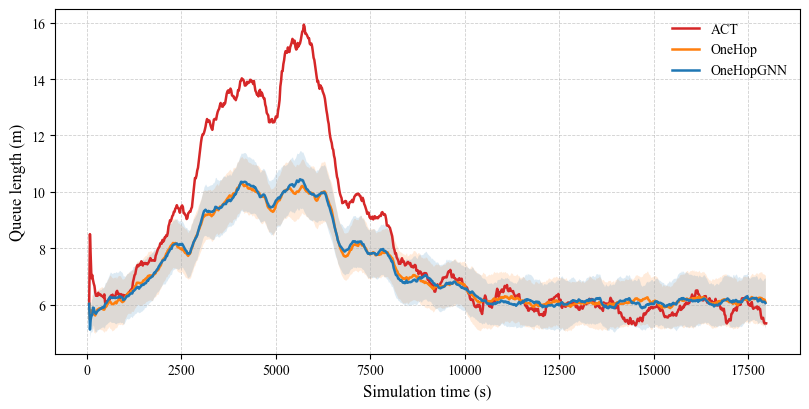

Saved to: test/queue_length_vs_time_weibull_70.png
Saved to: test/queue_length_vs_time_weibull_70.pdf


In [13]:
from pathlib import Path
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

# =========================
# CONFIG
# =========================
ROOT = Path("inference-results")          # project-root/inference-results
FLOW = "weibull_70"          # change as needed
SMOOTH_WINDOW = 20           # rolling window over timesteps
BAND_Z = 1.0                 # 1.0 = lighter band, 1.645 = wider band

CATEGORY_CONFIG = {
    "actuated":   {"label": "ACT",                 "color": "#d62728"},
    "onehop":     {"label": "OneHop",              "color": "#ff7f0e"},
    "onehop_gnn": {"label": "OneHopGNN", "color": "#1f77b4"},

    # uncomment if you also have them
    # "no_region":   {"label": "FD",         "color": "#000000"},
    # "centralized": {"label": "RegionWide", "color": "#2ca02c"},
}

# =========================
# ROBUST QUEUE XML PARSING
# =========================
def _remove_incomplete_data_tags(text: str) -> str:
    """
    Remove trailing incomplete <data ...> blocks while keeping complete
    <data>...</data> entries.
    """
    complete_data_pattern = re.compile(
        r"<data\b[^>]*>.*?</data\s*>",
        flags=re.IGNORECASE | re.DOTALL
    )

    complete_blocks = [m.span() for m in complete_data_pattern.finditer(text)]
    all_open_data_tags = list(re.finditer(r"<data\b[^>]*>", text, flags=re.IGNORECASE))

    cleaned = text
    for match in reversed(all_open_data_tags):
        start = match.start()
        inside_valid_block = any(lo <= start < hi for lo, hi in complete_blocks)
        if not inside_valid_block:
            cleaned = cleaned[:start]
            break
    return cleaned

def parse_queue_xml(xml_path: Path):
    """
    Parse SUMO queue.xml.

    Expected shape:
      <queue-export>
        <data timestep="...">
          <lanes>
            <lane id="E2D2_0" queueing_length="..." />
            ...
          </lanes>
        </data>
      </queue-export>
    """
    rows = []

    try:
        text = xml_path.read_text(encoding="utf-8", errors="ignore").strip()
    except Exception as e:
        print(f"[WARN] could not read {xml_path}: {e}")
        return rows

    if not text:
        print(f"[WARN] empty file: {xml_path}")
        return rows

    root = None

    # 1) normal parse
    try:
        root = ET.fromstring(text)
    except ET.ParseError:
        # 2) repair common truncated SUMO queue file
        repaired = _remove_incomplete_data_tags(text).rstrip()
        if "<queue-export" in repaired and "</queue-export>" not in repaired:
            repaired += "\n</queue-export>\n"

        try:
            root = ET.fromstring(repaired)
            print(f"[INFO] repaired queue file: {xml_path}")
        except ET.ParseError as e2:
            print(f"[WARN] could not parse {xml_path}: {e2}")
            return rows

    for data_node in root.findall(".//data"):
        timestep_raw = data_node.get("timestep")
        try:
            timestep_val = float(timestep_raw)
        except (TypeError, ValueError):
            continue

        lanes_parent = data_node.find("lanes")
        if lanes_parent is None:
            continue

        for lane_node in lanes_parent.findall("lane"):
            lane_id = lane_node.get("id")
            qlen_raw = lane_node.get("queueing_length")

            try:
                qlen_val = float(qlen_raw)
            except (TypeError, ValueError):
                continue

            rows.append({
                "timestep": timestep_val,
                "lane_id": lane_id,
                "queue_len": qlen_val,
            })

    return rows

def load_queue_run(run_dir: Path):
    """
    Read all *queue*.xml files inside one run directory.
    """
    rows = []
    for xml_path in sorted(run_dir.glob("*queue*.xml")):
        rows.extend(parse_queue_xml(xml_path))

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    df = df.dropna(subset=["timestep", "queue_len"]).copy()
    df = df.sort_values("timestep").reset_index(drop=True)
    return df

def load_category_queue_runs(root: Path, category: str, flow: str):
    """
    Supports both layouts:
      1) single-run:
         inference-results/actuated/weibull_60/queue.xml
      2) multi-run:
         inference-results/onehop/weibull_60/episode_401/queue.xml
         inference-results/onehop/weibull_60/episode_402/queue.xml
         ...
    """
    flow_dir = root / category / flow
    if not flow_dir.exists():
        print(f"[INFO] missing: {flow_dir}")
        return {}

    direct_xmls = list(flow_dir.glob("*queue*.xml"))
    if direct_xmls:
        df = load_queue_run(flow_dir)
        return {category: df} if not df.empty else {}

    run_map = {}
    for run_dir in sorted(flow_dir.iterdir()):
        if run_dir.is_dir():
            df = load_queue_run(run_dir)
            if not df.empty:
                run_map[run_dir.name] = df

    return run_map

# =========================
# AGGREGATION
# =========================
def aggregate_network_queue(run_dfs: dict, smooth_window: int = 20, band_z: float = 1.0):
    """
    For one controller/category:
      - each run -> timestep -> mean(queue_len) over all lanes
      - align timesteps across runs
      - mean/std across runs
      - rolling average smoothing
    """
    per_run_series = {}

    for run_name, rdf in run_dfs.items():
        if rdf is None or rdf.empty:
            continue

        s = rdf.groupby("timestep")["queue_len"].mean().sort_index()
        if not s.empty:
            per_run_series[run_name] = s

    if not per_run_series:
        return None, 0

    per_run_df = pd.DataFrame(per_run_series).sort_index()

    mean_ = per_run_df.mean(axis=1)
    std_ = per_run_df.std(axis=1, ddof=0).fillna(0.0)
    n_runs_ = per_run_df.notna().sum(axis=1)

    agg = pd.DataFrame({
        "timestep": per_run_df.index.values,
        "mean": mean_.values,
        "std": std_.values,
        "n_runs": n_runs_.values,
    }).sort_values("timestep").reset_index(drop=True)

    agg["mean_ma"] = agg["mean"].rolling(window=smooth_window, min_periods=1).mean()
    agg["std_ma"] = agg["std"].rolling(window=smooth_window, min_periods=1).mean()
    agg["upper_ma"] = agg["mean_ma"] + band_z * agg["std_ma"]
    agg["lower_ma"] = agg["mean_ma"] - band_z * agg["std_ma"]

    return agg, int(n_runs_.max())

# =========================
# LOAD ALL CATEGORIES
# =========================
all_data = {}
for category in CATEGORY_CONFIG:
    run_map = load_category_queue_runs(ROOT, category, FLOW)
    if run_map:
        all_data[category] = run_map

if not all_data:
    raise FileNotFoundError(
        f"No queue files found under {ROOT}. Check ROOT, FLOW, and category folder names."
    )

# =========================
# PLOT
# =========================
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

fig, ax = plt.subplots(figsize=(8.2, 4.2))

for category, meta in CATEGORY_CONFIG.items():
    if category not in all_data:
        continue

    agg, n_runs = aggregate_network_queue(
        all_data[category],
        smooth_window=SMOOTH_WINDOW,
        band_z=BAND_Z,
    )
    if agg is None or agg.empty:
        continue

    x = agg["timestep"].to_numpy()
    y = agg["mean_ma"].to_numpy()

    if n_runs > 1:
        ax.fill_between(
            x,
            agg["lower_ma"].to_numpy(),
            agg["upper_ma"].to_numpy(),
            color=meta["color"],
            alpha=0.15,
            linewidth=0,
        )

    ax.plot(
        x,
        y,
        label=meta["label"],
        color=meta["color"],
        linewidth=1.8,
    )

ax.set_xlabel("Simulation time (s)", fontsize=12)
ax.set_ylabel("Queue length (m)", fontsize=12)
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.6)
ax.legend(frameon=False, loc="best", fontsize=10)

# optional, to match your example exactly
# ax.set_xlim(0, 18000)

fig.tight_layout()

out_png = OUT_DIR / f"queue_length_vs_time_{FLOW}.png"
out_pdf = OUT_DIR / f"queue_length_vs_time_{FLOW}.pdf"
fig.savefig(out_png, dpi=250, bbox_inches="tight")
fig.savefig(out_pdf, dpi=250, bbox_inches="tight")
plt.show()

print(f"Saved to: {out_png}")
print(f"Saved to: {out_pdf}")

/var/folders/1c/9lp6w2ds2m991lq40qtl9x6h0000gn/T/ipykernel_15038/1845039796.py:153: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


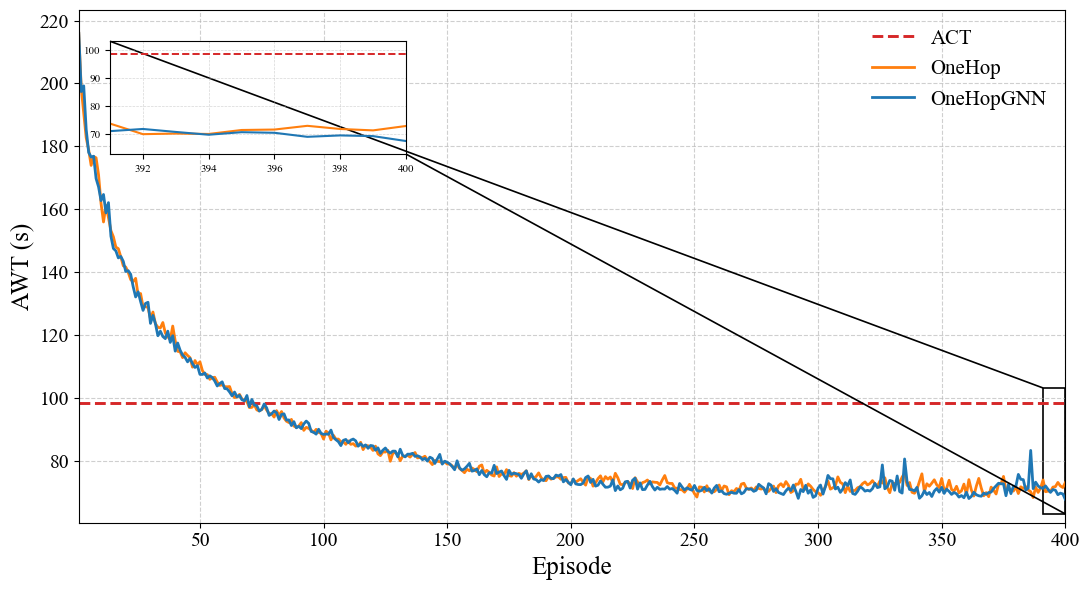

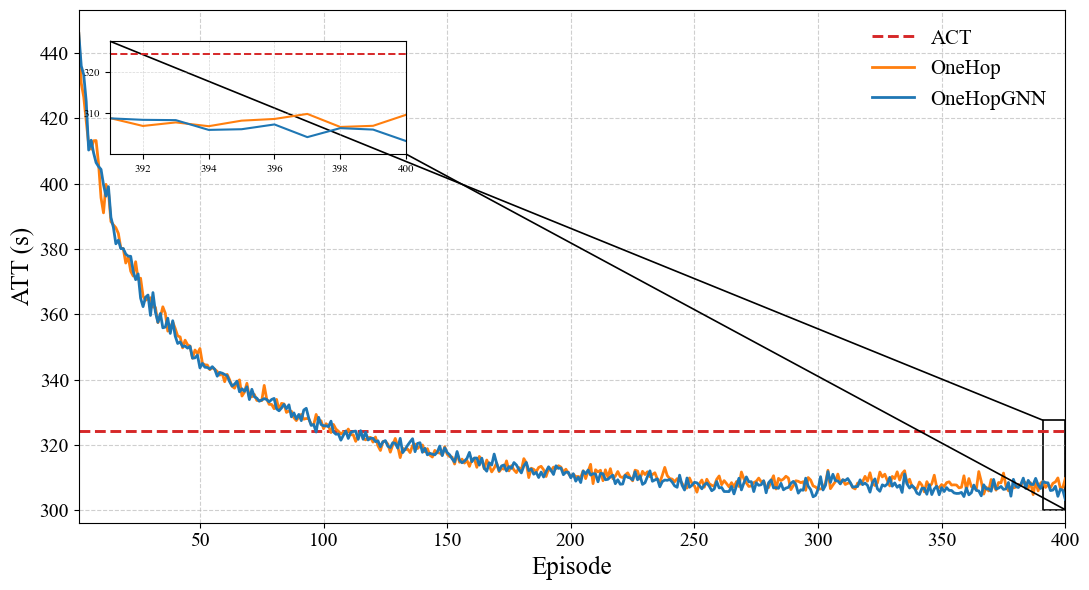

Saved: awt_vs_episode.png
Saved: att_vs_episode.png


In [19]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# =========================================================
# CONFIG
# =========================================================
FILES = {
    "OneHop": "inference_metrics/one-hop_metrics.txt",
    "OneHopGNN": "inference_metrics/one-hop-gnn-metrics.txt",
}

# Actuated steady baselines
ACT_AWT = 98.49
ACT_ATT = 324.34

# Optional styling
USE_ROLLING_MEAN = False
ROLLING_WINDOW = 5

# Inset settings
SHOW_INSET = True
INSET_LAST_N = 10   # zoom on last N episodes

# Line colors
COLORS = {
    "ACT": "#d62728",
    "OneHop": "#ff7f0e",
    "OneHopGNN": "#1f77b4",
}

# =========================================================
# PARSER
# =========================================================
def parse_metric_file(path):
    text = Path(path).read_text(encoding="utf-8", errors="ignore")

    pattern = re.compile(
        r"Episode\s+(\d+):\s*"
        r"Average meanTravelTime\s*:\s*([0-9.+\-eE]+)\s*"
        r"Average waitingTime:\s*([0-9.+\-eE]+)",
        flags=re.MULTILINE
    )

    rows = []
    for ep, att, awt in pattern.findall(text):
        rows.append({
            "episode": int(ep),
            "ATT": float(att),
            "AWT": float(awt),
        })

    if not rows:
        raise ValueError(f"No episode metrics found in {path}")

    df = pd.DataFrame(rows).sort_values("episode").reset_index(drop=True)

    if USE_ROLLING_MEAN:
        df["ATT_plot"] = df["ATT"].rolling(ROLLING_WINDOW, min_periods=1).mean()
        df["AWT_plot"] = df["AWT"].rolling(ROLLING_WINDOW, min_periods=1).mean()
    else:
        df["ATT_plot"] = df["ATT"]
        df["AWT_plot"] = df["AWT"]

    return df

# =========================================================
# LOAD DATA
# =========================================================
data = {}
for label, file_path in FILES.items():
    data[label] = parse_metric_file(file_path)

max_episode = max(df["episode"].max() for df in data.values())
min_episode = min(df["episode"].min() for df in data.values())

# =========================================================
# PLOTTER
# =========================================================
def make_learning_plot(metric_name, ylabel, act_value, out_name):
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]

    fig, ax = plt.subplots(figsize=(11, 6))

    # ACT horizontal baseline
    ax.axhline(
        act_value,
        color=COLORS["ACT"],
        linestyle="--",
        linewidth=2.1,
        label="ACT",
    )

    # Learned models
    for label, df in data.items():
        ax.plot(
            df["episode"],
            df[f"{metric_name}_plot"],
            linewidth=2.0,
            color=COLORS.get(label, None),
            label=label,
        )

    ax.set_xlabel("Episode", fontsize=18)
    ax.set_ylabel(ylabel, fontsize=18)
    ax.set_xlim(min_episode, max_episode)
    ax.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.tick_params(axis="both", labelsize=14)
    ax.legend(frameon=False, fontsize=15, loc="best")

    # Optional inset zoom on final episodes
    if SHOW_INSET:
        axins = inset_axes(ax, width="30%", height="22%", loc="upper left", borderpad=2.5)

        inset_start = max(min_episode, max_episode - INSET_LAST_N + 1)
        inset_end = max_episode

        axins.axhline(
            act_value,
            color=COLORS["ACT"],
            linestyle="--",
            linewidth=1.4,
        )

        y_vals = [act_value]

        for label, df in data.items():
            sub = df[(df["episode"] >= inset_start) & (df["episode"] <= inset_end)]
            axins.plot(
                sub["episode"],
                sub[f"{metric_name}_plot"],
                linewidth=1.5,
                color=COLORS.get(label, None),
            )
            y_vals.extend(sub[f"{metric_name}_plot"].tolist())

        axins.set_xlim(inset_start, inset_end)

        if y_vals:
            y_min = min(y_vals)
            y_max = max(y_vals)
            pad = max(0.5, (y_max - y_min) * 0.15)
            axins.set_ylim(y_min - pad, y_max + pad)

        axins.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
        axins.tick_params(axis="both", labelsize=8)

        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black", lw=1.2)

    fig.tight_layout()
    fig.savefig(out_name, dpi=300, bbox_inches="tight")
    plt.show()

# =========================================================
# MAKE THE TWO FIGURES
# =========================================================
make_learning_plot(
    metric_name="AWT",
    ylabel="AWT (s)",
    act_value=ACT_AWT,
    out_name=OUT_DIR / "awt_vs_episode.png",
)

make_learning_plot(
    metric_name="ATT",
    ylabel="ATT (s)",
    act_value=ACT_ATT,
    out_name=OUT_DIR / "att_vs_episode.png",
)

print("Saved: awt_vs_episode.png")
print("Saved: att_vs_episode.png")